In [1]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Data Collection

In [2]:
entry_data = pd.read_csv("https://www.immd.gov.hk/opendata/eng/transport/immigration_clearance/statistics_on_daily_passenger_traffic.csv")

In [3]:
entry_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47324 entries, 0 to 47323
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Date                 47324 non-null  object 
 1   Control Point        47324 non-null  object 
 2   Arrival / Departure  47324 non-null  object 
 3   Hong Kong Residents  47324 non-null  int64  
 4   Mainland Visitors    47324 non-null  int64  
 5   Other Visitors       47324 non-null  int64  
 6   Total                47324 non-null  int64  
 7   Unnamed: 7           0 non-null      float64
dtypes: float64(1), int64(4), object(3)
memory usage: 2.9+ MB


# Data Preprocessing & Cleaning

In [4]:
entry_data.drop(columns=["Unnamed: 7"], inplace=True)

These 3 entry points have since closed down, hence there have been no data points for these control Points

In [5]:
mask = ~entry_data["Control Point"].isin(["Hung Hom", "Sha Tau Kok", "Tuen Mun Ferry Terminal"])

entry_data = entry_data[mask]

In [6]:
entry_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 40768 entries, 0 to 47323
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Date                 40768 non-null  object
 1   Control Point        40768 non-null  object
 2   Arrival / Departure  40768 non-null  object
 3   Hong Kong Residents  40768 non-null  int64 
 4   Mainland Visitors    40768 non-null  int64 
 5   Other Visitors       40768 non-null  int64 
 6   Total                40768 non-null  int64 
dtypes: int64(4), object(3)
memory usage: 2.5+ MB


In [7]:
entry_data.duplicated().sum()

0

In [8]:
entry_data.isna().sum()

Date                   0
Control Point          0
Arrival / Departure    0
Hong Kong Residents    0
Mainland Visitors      0
Other Visitors         0
Total                  0
dtype: int64

In [9]:
entry_data["Date"] = pd.to_datetime(entry_data["Date"], format="%d-%m-%Y")

# Exploratory Data Analysis (EDA)

In [10]:
entry_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 40768 entries, 0 to 47323
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Date                 40768 non-null  datetime64[ns]
 1   Control Point        40768 non-null  object        
 2   Arrival / Departure  40768 non-null  object        
 3   Hong Kong Residents  40768 non-null  int64         
 4   Mainland Visitors    40768 non-null  int64         
 5   Other Visitors       40768 non-null  int64         
 6   Total                40768 non-null  int64         
dtypes: datetime64[ns](1), int64(4), object(2)
memory usage: 2.5+ MB


In [11]:
grouped_data = entry_data.groupby('Date', as_index=False).agg({
    'Hong Kong Residents': 'sum',
    'Mainland Visitors': 'sum',
    'Other Visitors': 'sum',
    'Total': 'sum'
})
grouped_data.head()

,Date,Hong Kong Residents,Mainland Visitors,Other Visitors,Total
0,2021-01-01,4178,290,42,4510
1,2021-01-02,4845,361,47,5253
2,2021-01-03,6462,415,99,6976
3,2021-01-04,6131,485,63,6679
4,2021-01-05,3704,222,80,4006


In [12]:
sns.set_style("whitegrid", {
    "grid.linestyle": "--",
    "grid.alpha": 0.6}) 

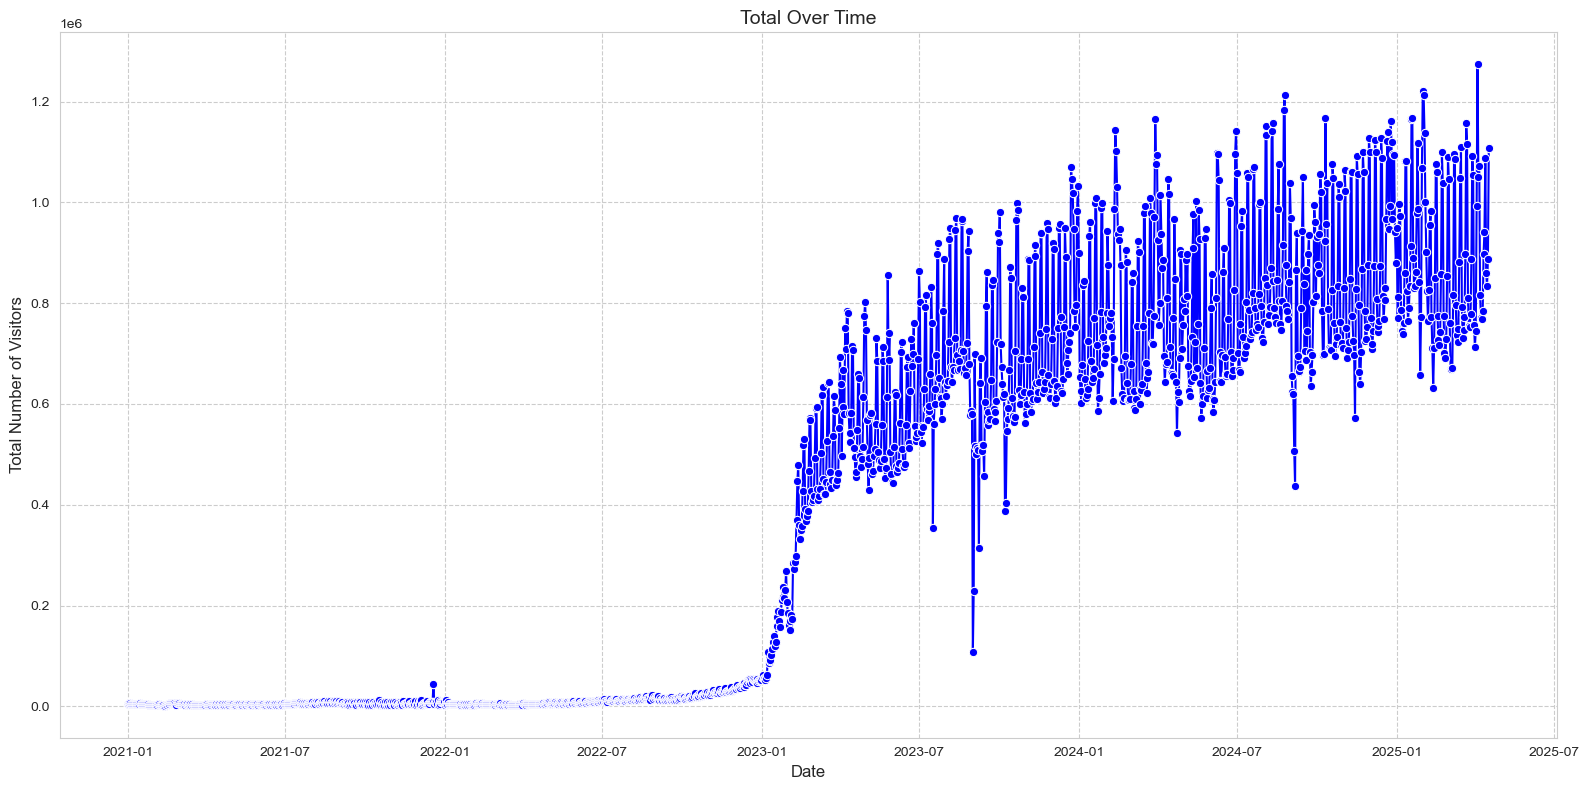

In [13]:
plt.figure(figsize=(16, 8))
sns.lineplot(data=grouped_data, x="Date", y="Total", marker="o", color="b", errorbar=None)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Total Number of Visitors", fontsize=12)
plt.title("Total Over Time", fontsize=14)
plt.tight_layout()
plt.show();

In [14]:
grouped_monthly_data = grouped_data.resample("ME", on="Date")["Hong Kong Residents","Mainland Visitors", "Other Visitors", "Total"].mean().round(0).reset_index()
grouped_monthly_data.head()

,Date,Hong Kong Residents,Mainland Visitors,Other Visitors,Total
0,2021-01-31,4029.0,227.0,66.0,4322.0
1,2021-02-28,3664.0,196.0,61.0,3921.0
2,2021-03-31,3273.0,248.0,53.0,3574.0
3,2021-04-30,3255.0,230.0,61.0,3546.0
4,2021-05-31,3384.0,233.0,65.0,3682.0


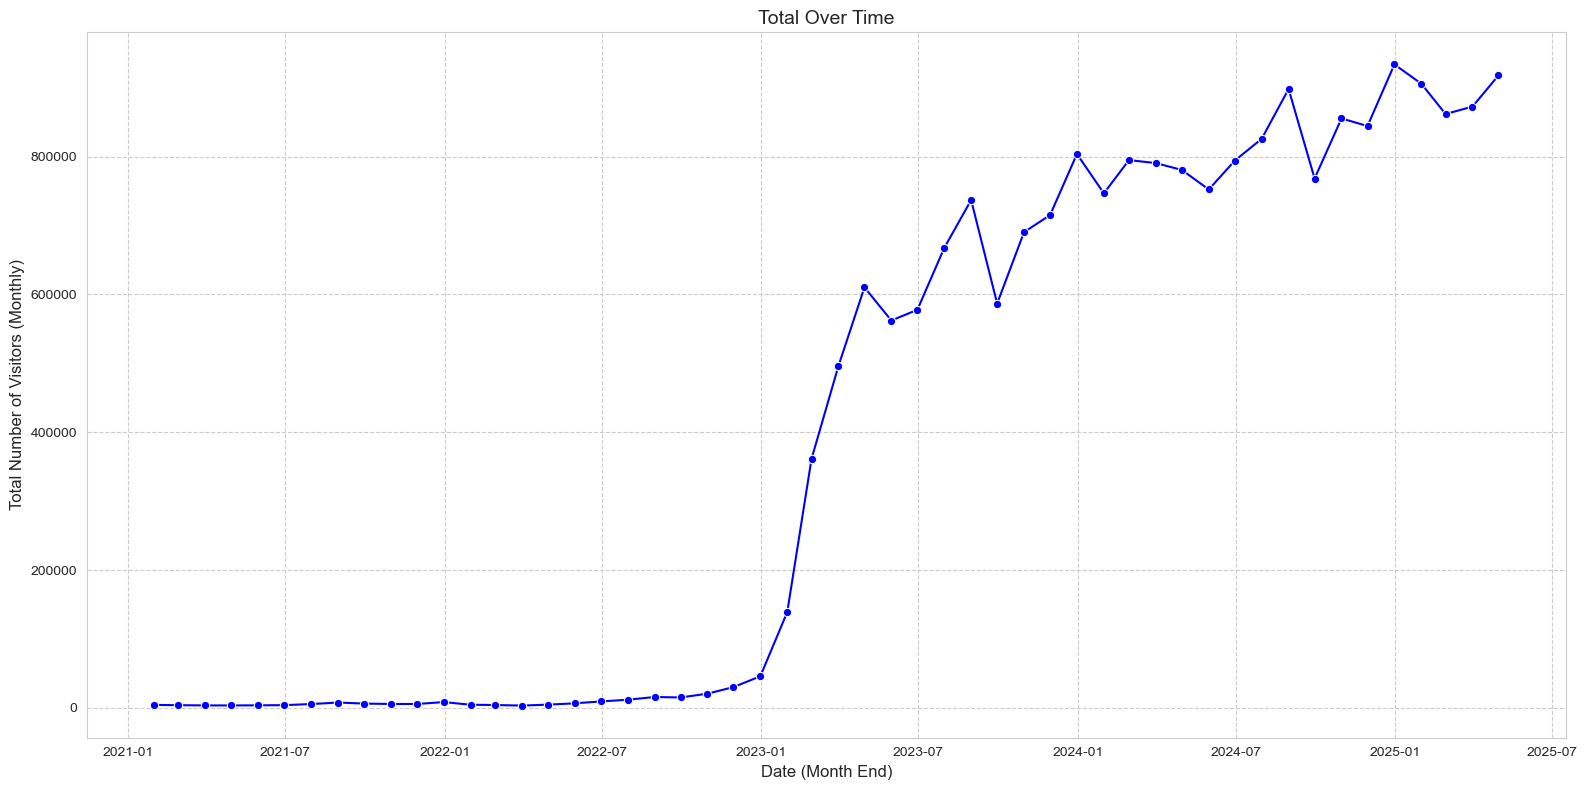

In [15]:
plt.figure(figsize=(16, 8))
sns.lineplot(data=grouped_monthly_data, x= "Date", y="Total", marker="o", color="b", errorbar=None)
plt.xlabel("Date (Month End)", fontsize=12)
plt.ylabel("Total Number of Visitors (Monthly)", fontsize=12)
plt.title("Total Over Time", fontsize=14)
plt.tight_layout()
plt.show();

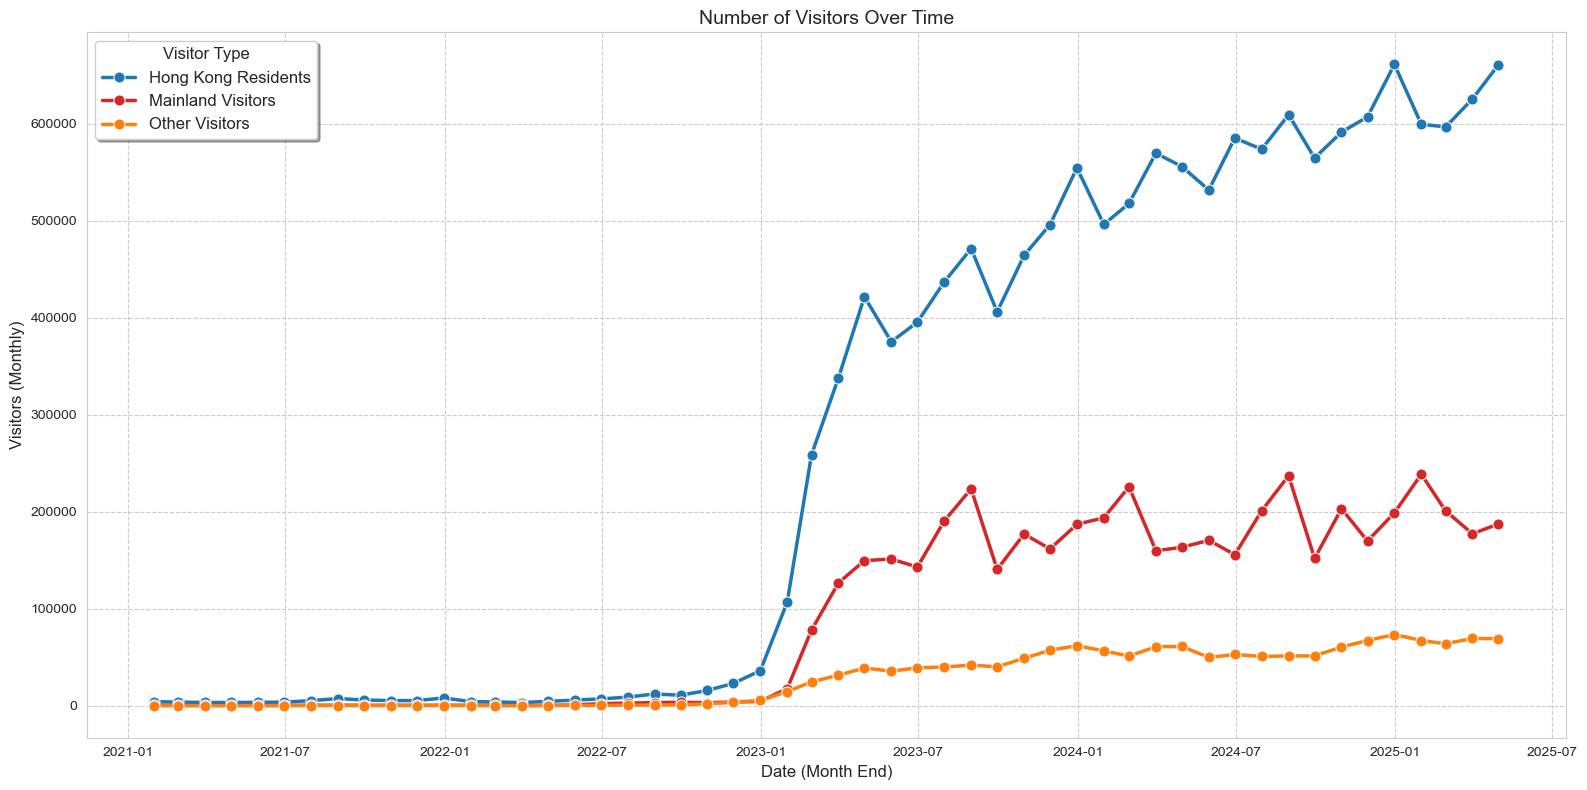

In [16]:
plt.figure(figsize=(16, 8))
color_palette = {"Hong Kong Residents": "#1f77b4",
                 "Mainland Visitors": "#d62728",    
                 "Other Visitors": "#ff7f0e"}

for column, color in color_palette.items():
    sns.lineplot(data=grouped_monthly_data, x="Date", y=column, marker="o", color=color, errorbar=None, linewidth=2.5, markersize=8, label=column)
    
plt.xlabel("Date (Month End)", fontsize=12)
plt.ylabel("Visitors (Monthly)", fontsize=12)
plt.title("Number of Visitors Over Time", fontsize=14)

legend = plt.legend(fontsize=12, framealpha=1, shadow=True, facecolor="white", bbox_to_anchor=(0, 1), loc="upper left")
legend.set_title("Visitor Type", prop={"size": 12})

plt.tight_layout()
plt.show();

In [17]:
monthly_data_mean = (
    entry_data.set_index("Date").groupby(["Control Point", "Arrival / Departure"]).resample("ME").agg({
        "Hong Kong Residents": "mean",
        "Mainland Visitors": "mean",
        "Other Visitors": "mean",
        "Total": "mean"
    }).round(0).reset_index())

monthly_data_mean.head()

,Control Point,Arrival / Departure,Date,Hong Kong Residents,Mainland Visitors,Other Visitors,Total
0,Airport,Arrival,2021-01-31,526.0,4.0,17.0,546.0
1,Airport,Arrival,2021-02-28,457.0,3.0,15.0,476.0
2,Airport,Arrival,2021-03-31,417.0,4.0,17.0,438.0
3,Airport,Arrival,2021-04-30,392.0,4.0,17.0,413.0
4,Airport,Arrival,2021-05-31,482.0,5.0,18.0,505.0


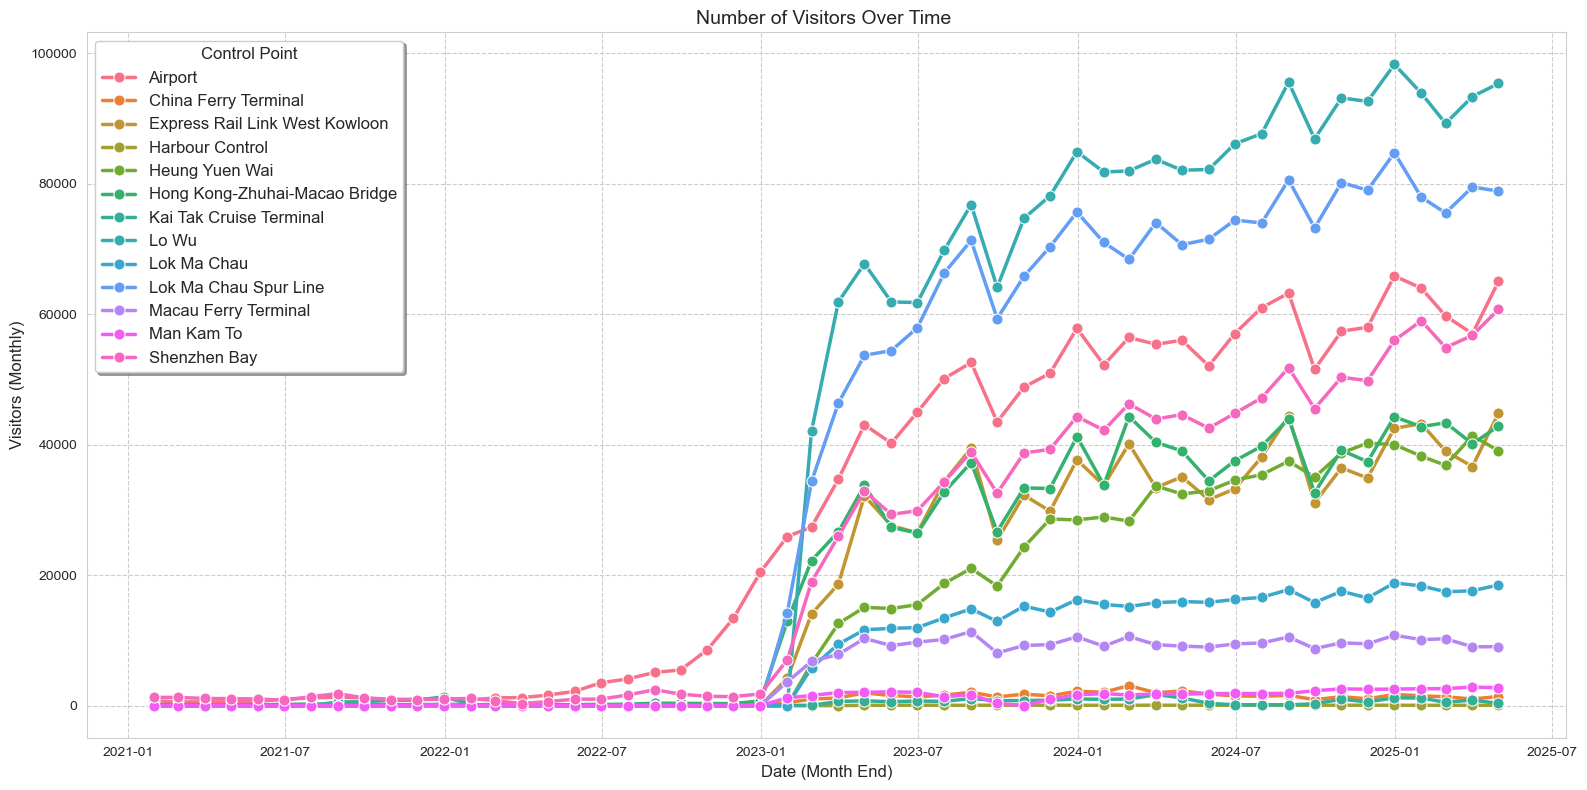

In [18]:
plt.figure(figsize=(16, 8))

sns.lineplot(data=monthly_data_mean, x="Date", y="Total", marker="o", hue = "Control Point", palette="husl", errorbar=None, linewidth=2.5, markersize=8)
    
plt.xlabel("Date (Month End)", fontsize=12)
plt.ylabel("Visitors (Monthly)", fontsize=12)
plt.title("Number of Visitors Over Time ", fontsize=14)

legend = plt.legend(fontsize=12, framealpha=1, shadow=True, facecolor="white", bbox_to_anchor=(0, 1), loc="upper left")
legend.set_title("Control Point", prop={"size": 12})

plt.tight_layout()
plt.show();

In [19]:
top_7_control_points = monthly_data_mean.groupby("Control Point").agg({
    "Total" : "sum"}).sort_values("Total", ascending=False).reset_index().head(7)

bot_6_control_points = monthly_data_mean.groupby("Control Point").agg({
    "Total" : "sum"}).sort_values("Total", ascending=True).reset_index().head(6)

top_7_control_points, bot_6_control_points

(                    Control Point      Total
 0                           Lo Wu  4336911.0
 1           Lok Ma Chau Spur Line  3767995.0
 2                         Airport  3061369.0
 3                    Shenzhen Bay  2394865.0
 4   Hong Kong-Zhuhai-Macao Bridge  1990020.0
 5  Express Rail Link West Kowloon  1840974.0
 6                  Heung Yuen Wai  1554740.0,
              Control Point     Total
 0          Harbour Control    2491.0
 1  Kai Tak Cruise Terminal   47038.0
 2     China Ferry Terminal   87404.0
 3               Man Kam To  103895.0
 4     Macau Ferry Terminal  519709.0
 5              Lok Ma Chau  814229.0)

In [20]:
top_7_list = top_7_control_points["Control Point"].values.tolist() 
bot_6_list = bot_6_control_points["Control Point"].values.tolist()

(top_7_list, bot_6_list)

(['Lo Wu',
  'Lok Ma Chau Spur Line',
  'Airport',
  'Shenzhen Bay',
  'Hong Kong-Zhuhai-Macao Bridge',
  'Express Rail Link West Kowloon',
  'Heung Yuen Wai'],
 ['Harbour Control',
  'Kai Tak Cruise Terminal',
  'China Ferry Terminal',
  'Man Kam To',
  'Macau Ferry Terminal',
  'Lok Ma Chau'])

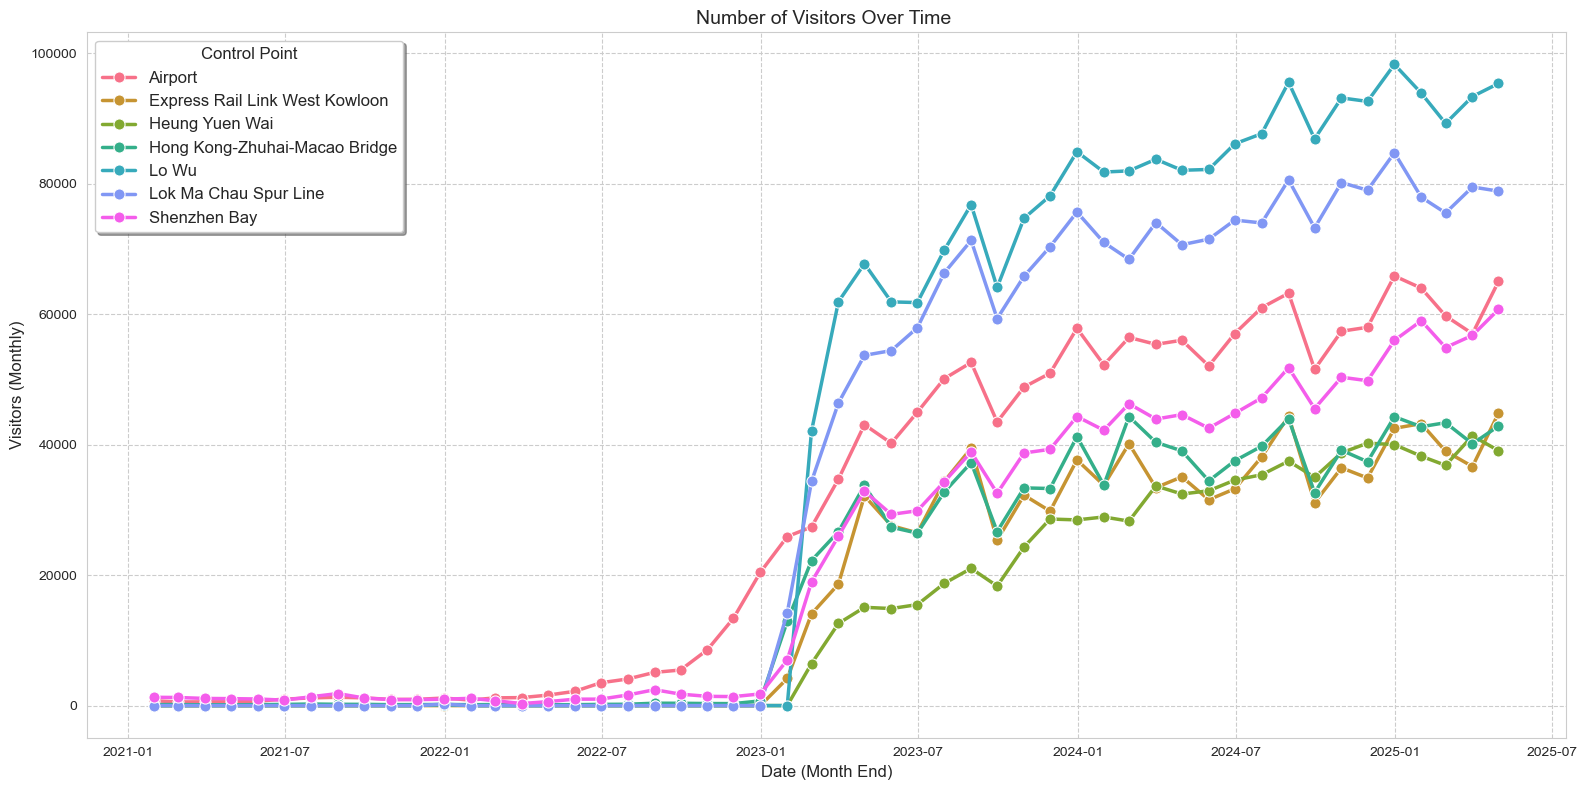

In [21]:
plt.figure(figsize=(16, 8))

sns.lineplot(data=monthly_data_mean[monthly_data_mean["Control Point"].isin(top_7_list)], x="Date", y="Total", marker="o", hue = "Control Point", palette="husl", errorbar=None, linewidth=2.5, markersize=8)
    
plt.xlabel("Date (Month End)", fontsize=12)
plt.ylabel("Visitors (Monthly)", fontsize=12)
plt.title("Number of Visitors Over Time ", fontsize=14)

legend = plt.legend(fontsize=12, framealpha=1, shadow=True, facecolor="white", bbox_to_anchor=(0, 1), loc="upper left")
legend.set_title("Control Point", prop={"size": 12})

plt.tight_layout()
plt.show();

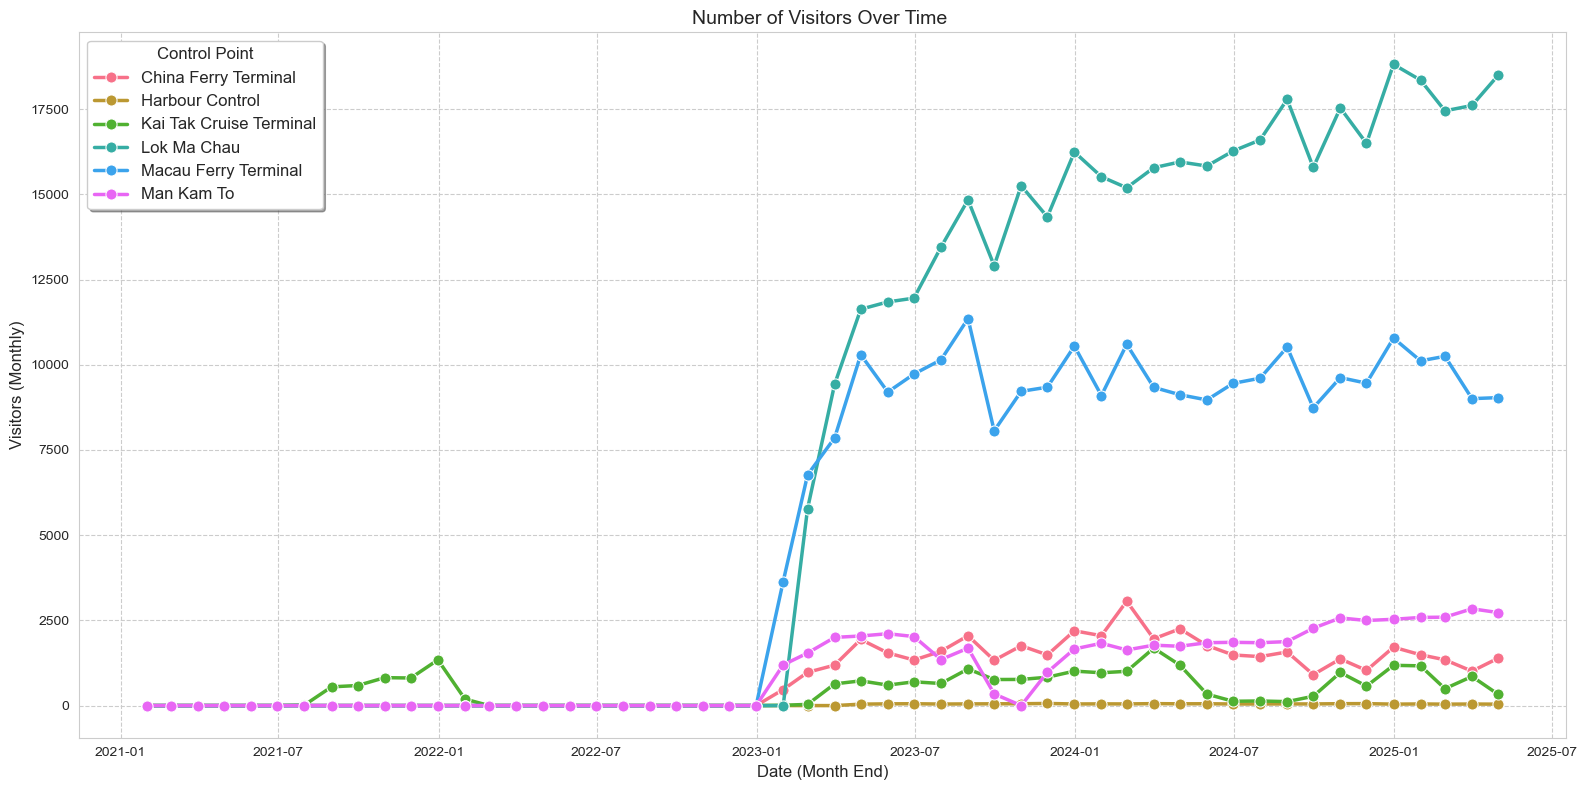

In [22]:
plt.figure(figsize=(16, 8))

sns.lineplot(data=monthly_data_mean[monthly_data_mean["Control Point"].isin(bot_6_list)], x="Date", y="Total", marker="o", hue = "Control Point", palette="husl", errorbar=None, linewidth=2.5, markersize=8)
    
plt.xlabel("Date (Month End)", fontsize=12)
plt.ylabel("Visitors (Monthly)", fontsize=12)
plt.title("Number of Visitors Over Time ", fontsize=14)

legend = plt.legend(fontsize=12, framealpha=1, shadow=True, facecolor="white", bbox_to_anchor=(0, 1), loc="upper left")
legend.set_title("Control Point", prop={"size": 12})

plt.tight_layout()
plt.show();

# Data Engineering

In [23]:
entry_data["Total_7day_avg"] = (entry_data.groupby("Control Point")["Total"].rolling(window=7, min_periods=1).mean().reset_index(level=0, drop=True))

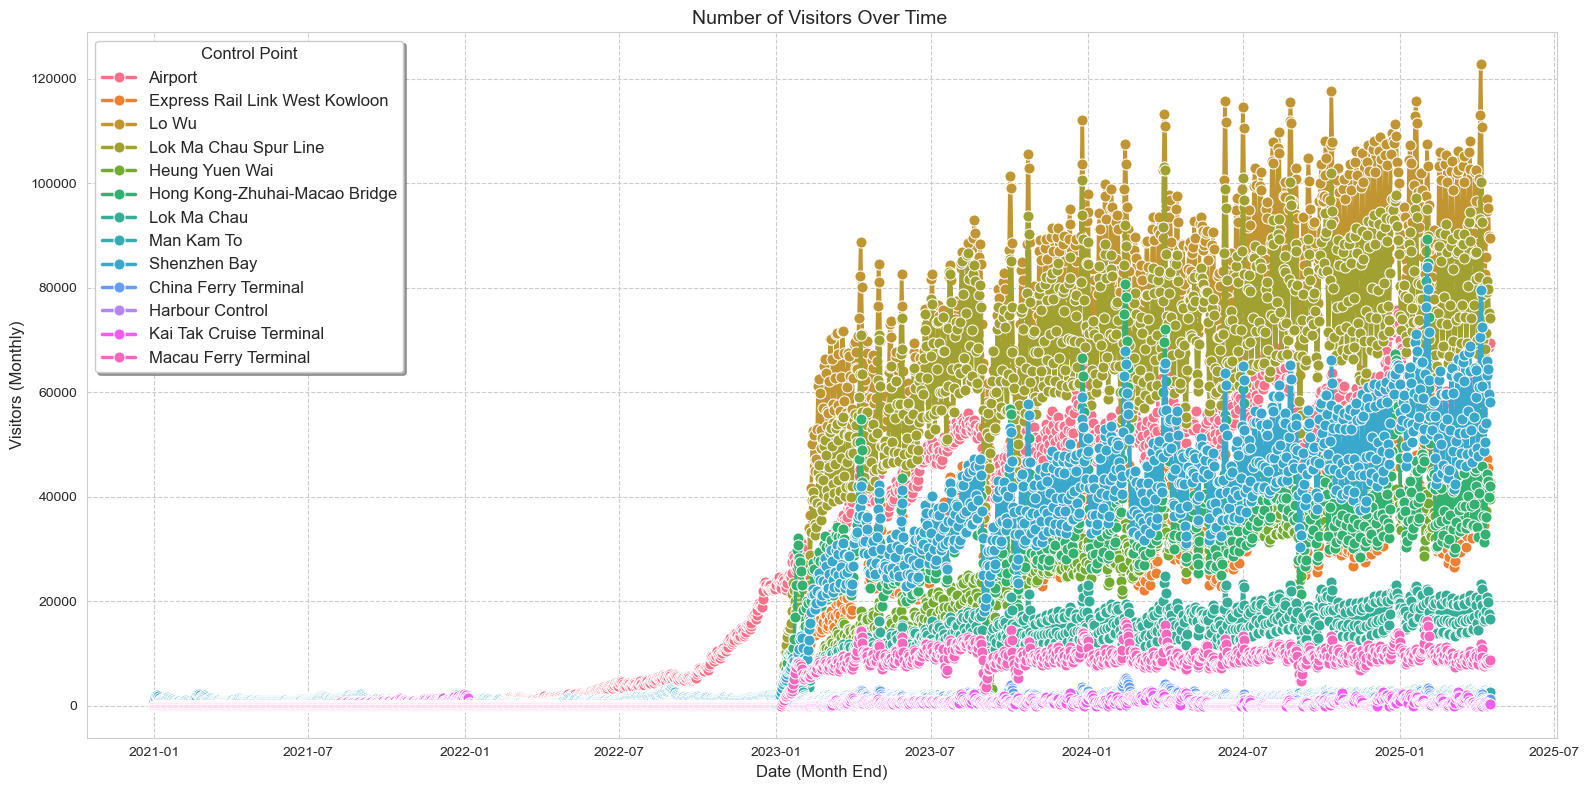

In [27]:
plt.figure(figsize=(16, 8))

sns.lineplot(data=entry_data, x="Date", y="Total_7day_avg", marker="o", hue = "Control Point", palette="husl", errorbar=None, linewidth=2.5, markersize=8)
    
plt.xlabel("Date (Month End)", fontsize=12)
plt.ylabel("Visitors (Monthly)", fontsize=12)
plt.title("Number of Visitors Over Time ", fontsize=14)

legend = plt.legend(fontsize=12, framealpha=1, shadow=True, facecolor="white", bbox_to_anchor=(0, 1), loc="upper left")
legend.set_title("Control Point", prop={"size": 12})

plt.tight_layout()
plt.show();

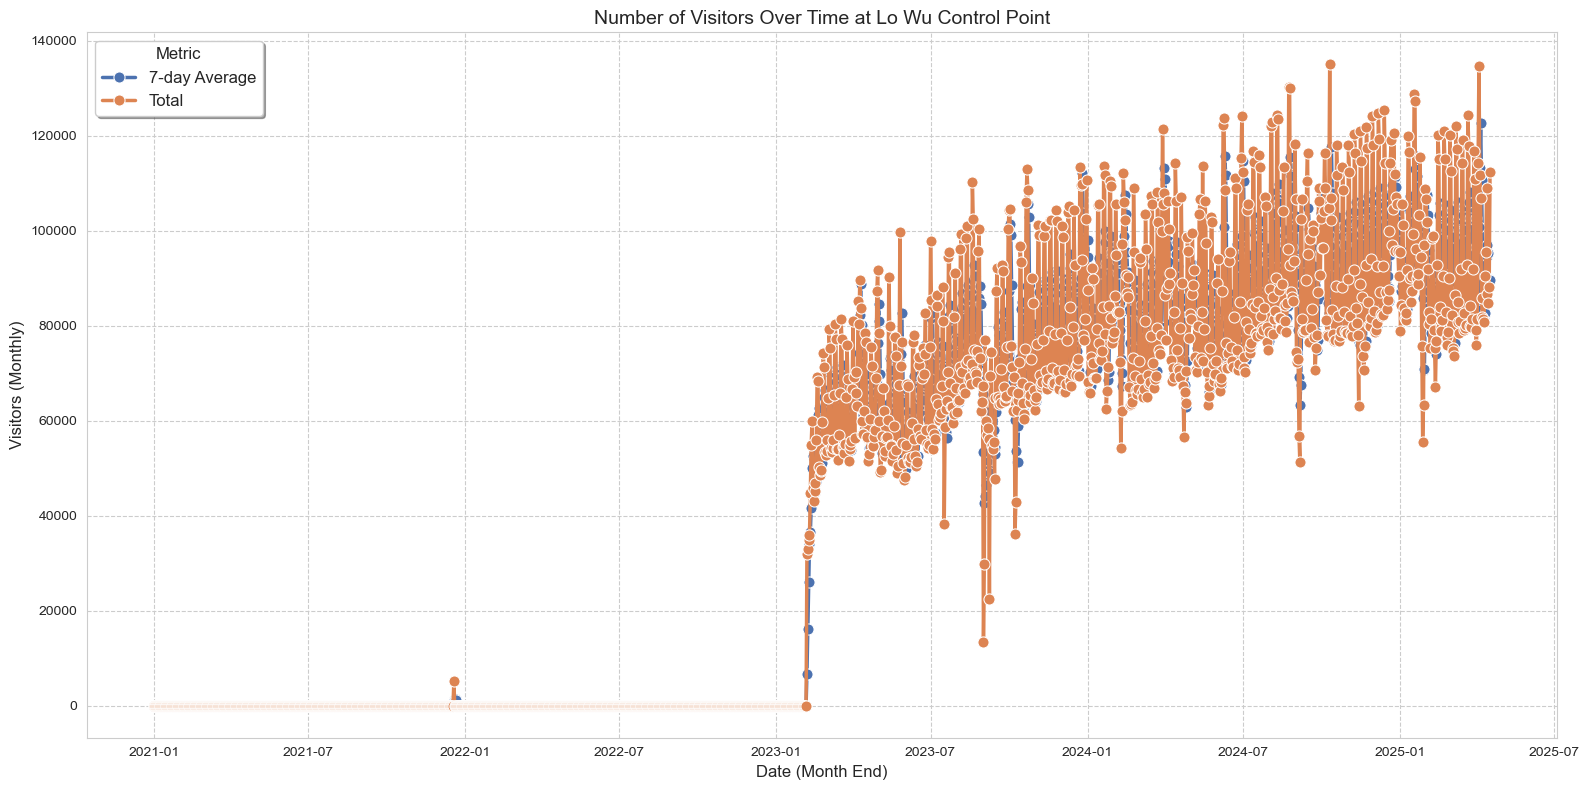

In [32]:
plt.figure(figsize=(16, 8))

sns.lineplot(data=entry_data[entry_data["Control Point"] == "Lo Wu"], x="Date", y="Total_7day_avg", marker="o", color="#4C72B0",
             errorbar=None, linewidth=2.5, markersize=8, label="7-day Average")

sns.lineplot(data=entry_data[entry_data["Control Point"] == "Lo Wu"], x="Date", y="Total", marker="o", color="#DD8452",
             errorbar=None, linewidth=2.5, markersize=8, label="Total")
    
plt.xlabel("Date (Month End)", fontsize=12)
plt.ylabel("Visitors (Monthly)", fontsize=12)
plt.title("Number of Visitors Over Time at Lo Wu Control Point", fontsize=14)

legend = plt.legend(fontsize=12, framealpha=1, shadow=True, facecolor="white", bbox_to_anchor=(0, 1), loc="upper left", title="Metric")
legend.get_title().set_fontsize(12)

plt.tight_layout()
plt.show()